In [30]:
import pandas as pd
import numpy as np


In [31]:
df = pd.read_csv(r'C:\Users\hp\OneDrive\Documents\Desktop\fake news detection\Data\cleaned_data.csv')
df.head()

,clean_content,label
0,law enforcement high alert following threat co...,1
1,unbelievable obamas attorney general say charl...,1
2,bobby jindal raised hindu us story christian c...,0
3,satan russia unvelis image terrifying new supe...,1
4,time christian group sue amazon splc designati...,1


In [32]:
df.shape


(71537, 2)

In [33]:
df = df.dropna(subset=['clean_content'])

In [34]:
from sklearn.model_selection import train_test_split
X = df['clean_content']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


# Bag of Words

In [35]:
from sklearn.feature_extraction.text import CountVectorizer
bow_vectorizer = CountVectorizer(max_features=5000,ngram_range=(1,2))
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

In [36]:
from sklearn.naive_bayes import MultinomialNB
bow_model = MultinomialNB()
bow_model.fit(X_train_bow, y_train)
y_pred_bow = bow_model.predict(X_test_bow)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
acc_bow = accuracy_score(y_test, y_pred_bow)
print("BoW Model Accuracy:", acc_bow)
print("BoW Model Classification Report:\n", classification_report(y_test, y_pred_bow))
print("BoW Model Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bow))


BoW Model Accuracy: 0.8809244026635331
BoW Model Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.88      8724
           1       0.88      0.89      0.88      9147

    accuracy                           0.88     17871
   macro avg       0.88      0.88      0.88     17871
weighted avg       0.88      0.88      0.88     17871

BoW Model Confusion Matrix:
 [[7588 1136]
 [ 992 8155]]


# TF-IDF

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000,ngram_range=(1,2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


In [38]:
tfidf_model = MultinomialNB()
tfidf_model.fit(X_train_tfidf, y_train)
y_pred_tfidf = tfidf_model.predict(X_test_tfidf)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print("TF-IDF Model Accuracy:", acc_tfidf)
print("TF-IDF Model Classification Report:\n", classification_report(y_test, y_pred_tfidf))
print("TF-IDF Model Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tfidf))


TF-IDF Model Accuracy: 0.8565273347882043
TF-IDF Model Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.83      0.85      8724
           1       0.84      0.89      0.86      9147

    accuracy                           0.86     17871
   macro avg       0.86      0.86      0.86     17871
weighted avg       0.86      0.86      0.86     17871

TF-IDF Model Confusion Matrix:
 [[7203 1521]
 [1043 8104]]


# Word2Vec

In [39]:
from gensim.models import Word2Vec

In [40]:
sentences = [text.split() for text in X_train]

In [41]:
w2v_model = Word2Vec(sentences,vector_size=100,window=5,min_count=2,workers=4)

In [42]:
def avgW2vec(text,model):
    word =text.split()
    vectors=[]
    for w in word:
        if w in model.wv:
            vectors.append(model.wv[w])
    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [43]:
X_train_w2v = np.array([avgW2vec(text, w2v_model) for text in X_train])
X_test_w2v = np.array([avgW2vec(text, w2v_model) for text in X_test])

In [44]:
from sklearn.naive_bayes import GaussianNB

model_w2v = GaussianNB()

model_w2v.fit(X_train_w2v, y_train)

pred_w2v = model_w2v.predict(X_test_w2v)

from sklearn.metrics import accuracy_score

acc_w2v = accuracy_score(y_test, pred_w2v)

print("Word2Vec Accuracy:", acc_w2v)

Word2Vec Accuracy: 0.7924010967489228


In [45]:
results = pd.DataFrame({
    "Feature Method": ["Bag of Words", "TF-IDF", "Word2Vec"],
    "Accuracy": [acc_bow, acc_tfidf, acc_w2v]
})

results

,Feature Method,Accuracy
0,Bag of Words,0.880924
1,TF-IDF,0.856527
2,Word2Vec,0.792401


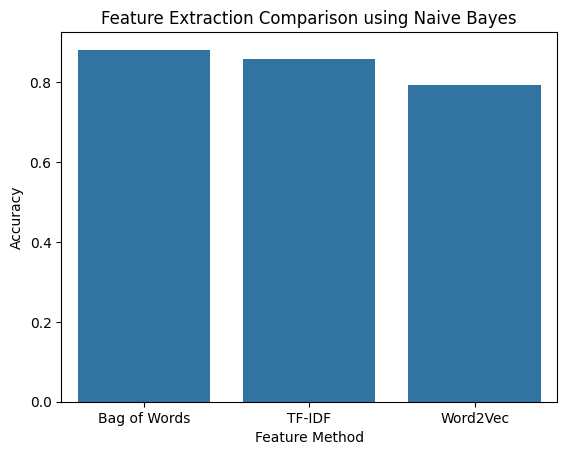

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Feature Method", y="Accuracy", data=results)

plt.title("Feature Extraction Comparison using Naive Bayes")

plt.show()

In [48]:
import joblib
joblib.dump(bow_model, "../Models/fake_news_model.pkl")

['../Models/fake_news_model.pkl']

In [49]:
joblib.dump(bow_vectorizer, "../Models/bow_vectorizer.pkl")

['../Models/bow_vectorizer.pkl']